In [4]:
import pandas as pd
import numpy as np

# 1. Đọc file
df = pd.read_csv('dataset.csv', na_values='..')

# 2. Lọc cực mạnh: Chỉ giữ lại các dòng có Country Code dài đúng 3 ký tự và viết hoa
# Điều này sẽ loại bỏ hoàn toàn các dòng "Code", "Data từ database...", "Last Updated..." ở cuối file
df = df[df['Country Code'].str.len() == 3]

# 3. Xóa các cột hoàn toàn trống (nếu có)
df = df.dropna(axis=1, how='all')

print("Danh sách các quốc gia còn lại (Phải sạch 100%):")
print(df['Country Name'].unique())

Danh sách các quốc gia còn lại (Phải sạch 100%):
['United States' 'United Kingdom' 'France' 'China' 'Germany' 'Japan'
 'India']


In [5]:
# 1. Xác định các cột định danh và các cột năm
id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
# Chỉ lấy những cột có định dạng số năm bên trong ngoặc []
year_cols = [col for col in df.columns if '[' in col]

# 2. Thực hiện "Melt" (chuyển từ ngang sang dọc)
df_long = df.melt(id_vars=id_vars, value_vars=year_cols, 
                  var_name='Year_Raw', value_name='Value')

# 3. Làm sạch cột Year
# Sử dụng r'(\d+)' để lấy các chữ số đầu tiên (ví dụ: 2000)
# Thêm .dropna() để loại bỏ các dòng không trích xuất được năm trước khi đổi sang int
df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d+)')[0]

# Xóa các dòng mà cột Year bị NaN (nếu có) để tránh lỗi convert
df_long = df_long.dropna(subset=['Year'])

# Bây giờ mới chuyển sang kiểu int an toàn
df_long['Year'] = df_long['Year'].astype(int)

# Xóa cột Year_Raw cũ cho gọn
df_long = df_long.drop(columns=['Year_Raw'])

# 4. Chuyển đổi Value sang kiểu số (float)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

print("Đã xử lý xong cột Year!")
display(df_long.head())

Đã xử lý xong cột Year!


,Country Name,Country Code,Series Name,Series Code,Value,Year
0,United States,USA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,NaN,2000
1,United States,USA,Population ages 0-14 (% of total population),SP.POP.0014.TO.ZS,21.163438,2000
2,United States,USA,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,66.650745,2000
3,United States,USA,Population ages 65 and above (% of total popul...,SP.POP.65UP.TO.ZS,12.185817,2000
4,United States,USA,Urban population (% of total population),SP.URB.TOTL.IN.ZS,79.074090,2000


In [6]:
# Kiểm tra xem mỗi nước/chỉ số bị thiếu bao nhiêu % dữ liệu
missing_info = df_long.groupby(['Country Name', 'Series Name'])['Value'].apply(lambda x: x.isnull().mean() * 100)
print("Phần trăm dữ liệu thiếu theo từng chỉ số:\n", missing_info)

# PHƯƠNG ÁN XỬ LÝ: 
# Với bài toán so sánh cường quốc, ta nên dùng phép nội suy (Interpolate) 
# để lấp đầy các khoảng trống nhỏ giữa các năm.
df_long['Value'] = df_long.groupby(['Country Name', 'Series Name'])['Value'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Xóa bỏ các dòng vẫn còn NaN sau khi nội suy (thường là do thiếu cả một dải năm dài)
df_clean = df_long.dropna(subset=['Value'])

Phần trăm dữ liệu thiếu theo từng chỉ số:
 Country Name    Series Name                                         
China           GDP per capita (current US$)                             3.846154
                Individuals using the Internet (% of population)         3.846154
                Population ages 0-14 (% of total population)             3.846154
                Population ages 15-64 (% of total population)            3.846154
                Population ages 65 and above (% of total population)     3.846154
                School enrollment, tertiary (% gross)                    3.846154
                Urban population (% of total population)                 3.846154
France          GDP per capita (current US$)                             3.846154
                Individuals using the Internet (% of population)         3.846154
                Population ages 0-14 (% of total population)             3.846154
                Population ages 15-64 (% of total population)       

In [7]:
# Tạo bảng Pivot: Mỗi dòng là một cặp (Quốc gia, Năm), mỗi cột là một chỉ số (Series Name)
df_final = df_clean.pivot_table(index=['Country Name', 'Country Code', 'Year'], 
                                columns='Series Name', 
                                values='Value').reset_index()

# Đổi tên cột cho ngắn gọn dễ dùng trong code
df_final.columns.name = None
df_final = df_final.rename(columns={
    'GDP per capita (current US$)': 'GDP_per_capita',
    'Individuals using the Internet (% of population)': 'Internet_Usage',
    'Population ages 0-14 (% of total population)': 'Pop_0_14',
    'Population ages 15-64 (% of total population)': 'Pop_15_64',
    'Population ages 65 and above (% of total population)': 'Pop_65_plus',
    'School enrollment, tertiary (% gross)': 'Tertiary_Enrollment',
    'Urban population (% of total population)': 'Urban_Population'
})

print("Dữ liệu đã sẵn sàng để phân tích!")
display(df_final.head())

Dữ liệu đã sẵn sàng để phân tích!


,Country Name,Country Code,Year,GDP_per_capita,Internet_Usage,Pop_0_14,Pop_15_64,Pop_65_plus,Tertiary_Enrollment,Urban_Population
0,China,CHN,2000,969.199514,1.77591,24.544096,68.438428,7.017476,7.57778,36.432023
1,China,CHN,2001,1065.405976,2.63965,23.806368,68.980116,7.213517,9.28069,37.659744
2,China,CHN,2002,1163.559577,4.59570,22.928309,69.670062,7.401629,11.80508,39.089783
3,China,CHN,2003,1306.972454,6.20000,22.042929,70.377445,7.579627,14.51397,40.530231
4,China,CHN,2004,1530.927262,7.30000,21.186430,71.076319,7.737251,16.90044,41.760014


## Mục tiêu phân tích 1: So sánh xu hướng phát triển nguồn nhân lực chất lượng cao (Trình độ Đại học) giữa các cường quốc

### 1. Chỉ số sử dụng
*   **Trường dữ liệu:** `School enrollment, tertiary (% gross)` - Tỷ lệ nhập học cấp bậc Đại học/Sau phổ thông.
*   **Ý nghĩa của chỉ số:** Đây là tỷ lệ giữa tổng số sinh viên đăng ký học đại học (không phân biệt độ tuổi) so với tổng dân số trong độ tuổi chính thức tương ứng với cấp học này. Chỉ số này phản ánh khả năng tiếp cận giáo dục bậc cao của người dân.

### 2. Giải thích lý do lựa chọn trường dữ liệu
*   **Phù hợp với mục tiêu:** Để đánh giá sức mạnh xã hội của một cường quốc, trình độ dân trí cao cấp là thước đo quan trọng nhất. Nó phản ánh khả năng cung ứng nguồn lao động có trình độ kỹ thuật và tư duy cao, là động lực chính thúc đẩy kinh tế tri thức.
*   **Giải thích tại sao lựa chọn:** Việc so sánh chỉ số này giữa 7 quốc gia (Mỹ, Anh, Pháp, Đức, Nhật, Trung Quốc, Ấn Độ) giúp làm rõ quốc gia nào đang ưu tiên đầu tư vào giáo dục để tạo ra lợi thế cạnh tranh dài hạn về công nghệ và quản lý.

### 3. Loại biểu đồ: **Line Chart (Biểu đồ đường)**

### 4. Giải thích lý do lựa chọn
*   **Tính chất dữ liệu:** Đây là dữ liệu chuỗi thời gian (Time-series) kéo dài liên tục từ năm 2000 đến 2020. Biểu đồ đường là lựa chọn tối ưu nhất để thể hiện sự biến động và xu hướng qua thời gian.
*   **Khả năng so sánh đa quốc gia:** Với 7 quốc gia, việc sử dụng các đường màu sắc khác nhau giúp người xem dễ dàng nhận diện vị thế tương đối (ai đang dẫn đầu, ai đang bám đuổi) và tốc độ thay đổi (thông qua độ dốc của đường).
*   **Đảm bảo sự rõ ràng:** Biểu đồ đường giúp làm nổi bật sự bứt phá thần tốc của Trung Quốc so với các nước phát triển, điều mà các loại biểu đồ khác khó thể hiện rõ nét trên một trục thời gian dài.


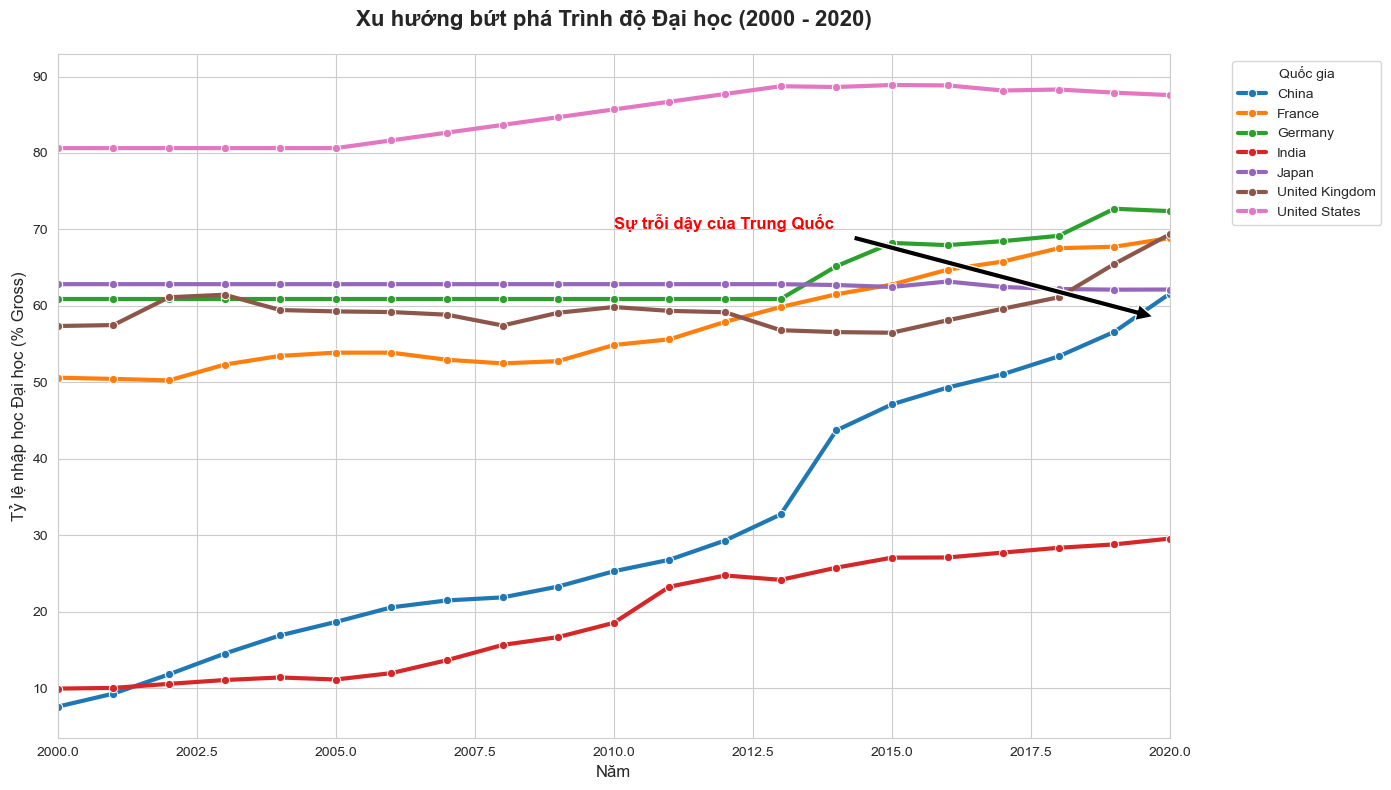

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập phong cách cho biểu đồ
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 2. Vẽ biểu đồ đường
# Chú ý: Chúng ta dùng df_final từ bước tiền xử lý trước đó
ax = sns.lineplot(
    data=df_final, 
    x='Year', 
    y='Tertiary_Enrollment', 
    hue='Country Name', 
    linewidth=3, 
    marker='o',  # Thêm dấu chấm tại các năm có dữ liệu thực
    markersize=6
)

# 3. Trang trí biểu đồ
plt.title('Xu hướng bứt phá Trình độ Đại học (2000 - 2020)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tỷ lệ nhập học Đại học (% Gross)', fontsize=12)
plt.legend(title='Quốc gia', bbox_to_anchor=(1.05, 1), loc='upper left')

# Giới hạn trục X từ 2000 đến 2020 để biểu đồ tập trung
plt.xlim(2000, 2020)

# Thêm ghi chú cho điểm đặc biệt (Ví dụ: Trung Quốc)
# Bạn có thể điều chỉnh tọa độ dựa trên dữ liệu thật của bạn
plt.annotate('Sự trỗi dậy của Trung Quốc', 
             xy=(2020, 58), xytext=(2010, 70),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

## PHÂN TÍCH VÀ RÚT RA KẾT LUẬN (MỤC TIÊU 1)

### 1. Phân tích kết quả từ biểu đồ
*   **Sự bứt phá của Trung Quốc (Đường xanh đậm):** Đây là điểm nhấn quan trọng nhất. Từ mức thấp nhất nhóm vào năm 2000 (dưới 10%), Trung Quốc đã có tốc độ tăng trưởng dốc đứng, vượt qua mức 50% vào năm 2018 và tiệm cận trình độ các nước phát triển vào năm 2020.
*   **Vị thế dẫn đầu của Mỹ (Đường hồng):** Hoa Kỳ luôn duy trì tỷ lệ cao nhất trong suốt 20 năm (dao động từ 80% đến gần 90%), khẳng định vị thế siêu cường giáo dục ổn định nhất thế giới.
*   **Sự trỗi dậy của Đức (Đường xanh lá):** Sau giai đoạn 2000-2012 đi ngang, Đức đã có bước nhảy vọt từ sau năm 2013, vươn lên vị trí thứ 2 trong nhóm cường quốc phương Tây về tỷ lệ nhập học đại học.
*   **Ấn Độ (Đường đỏ):** Có sự tăng trưởng bền bỉ nhưng tốc độ chậm hơn so với Trung Quốc. Đến năm 2020, Ấn Độ vẫn ở mức thấp nhất trong 7 nước (khoảng 30%), cho thấy còn nhiều dư địa để phát triển nguồn nhân lực.

### 2. Nhận xét và xu hướng rút ra từ dữ liệu
*   **Xu hướng toàn cầu:** Tất cả 7 cường quốc đều có tỷ lệ nhập học đại học tăng cao hơn so với năm 2000. Điều này cho thấy giáo dục bậc cao đã trở thành tiêu chuẩn chung cho lực lượng lao động tại các nền kinh tế lớn.
*   **Sự hội tụ (Convergence):** Khoảng cách về trình độ dân trí giữa nhóm các nước đang phát triển (Trung Quốc) và nhóm nước phát triển lâu đời đang được thu hẹp một cách ngoạn mục.

### 3. Kết luận
Sức mạnh xã hội của **Trung Quốc** đang chuyển dịch mạnh mẽ sang nền tảng tri thức cao cấp. Trong khi đó, **Hoa Kỳ và Đức** vẫn giữ vững ưu thế tuyệt đối về nền tảng đào tạo tinh hoa, tạo tiền đề vững chắc cho việc duy trì sức cạnh tranh kinh tế toàn cầu. Sự đầu tư vào giáo dục đại học chính là lời giải thích cho sức mạnh của các cường quốc này.

# Mục tiêu phân tích 2: So sánh Cơ cấu Dân số và mức độ Già hóa giữa các cường quốc (Năm 2020)

### 1. Chỉ số sử dụng

*   **Trường dữ liệu:** 
    *   `Population ages 0-14 (% of total population)` - Tỷ lệ trẻ em.
    *   `Population ages 15-64 (% of total population)` - Tỷ lệ độ tuổi lao động.
    *   `Population ages 65 and above (% of total population)` - Tỷ lệ người già.
*   **Ý nghĩa của chỉ số:** Các chỉ số này chia dân số thành 3 nhóm chức năng chính. Tổng của chúng bằng 100%, giúp phản ánh "hình thể" nhân khẩu học, gánh nặng phụ thuộc và tiềm năng nguồn nhân lực của một quốc gia.

### 2. Giải thích lý do lựa chọn trường dữ liệu

*   **Phù hợp với mục tiêu:** Để đánh giá sức mạnh xã hội bền vững, cơ cấu tuổi là yếu tố then chốt. Nhóm 15-64 quyết định sức mạnh kinh tế hiện tại, trong khi nhóm 0-14 và 65+ đại diện cho áp lực lên hệ thống giáo dục, y tế và an sinh xã hội.
*   **Giải thích tại sao lựa chọn:** Việc kết hợp 3 trường dữ liệu này cho phép chúng ta nhìn thấy sự tương phản rõ rệt giữa các cường quốc "già" (như Nhật Bản, Đức) và các cường quốc "trẻ" (như Ấn Độ), từ đó dự báo được lợi thế cạnh tranh về lao động trong tương lai.

### 3. Loại biểu đồ: **Stacked Bar Chart (Biểu đồ cột chồng)**

### 4. Giải thích lý do lựa chọn

*   **Tính chất dữ liệu:** Vì tổng các nhóm tuổi luôn là 100%, biểu đồ cột chồng là lựa chọn tối ưu nhất để thể hiện mối quan hệ giữa các phần so với tổng thể (Part-to-whole).
*   **Khả năng so sánh:** Biểu đồ này giúp người xem so sánh trực diện quy mô của từng phân khúc tuổi giữa 7 quốc gia chỉ trong một cái nhìn duy nhất.
*   **Sự trực quan:** Sự phân tách màu sắc giúp làm nổi bật "gánh nặng người già" hoặc "lợi thế trẻ em" của từng nước một cách rõ rệt hơn so với các loại biểu đồ khác.

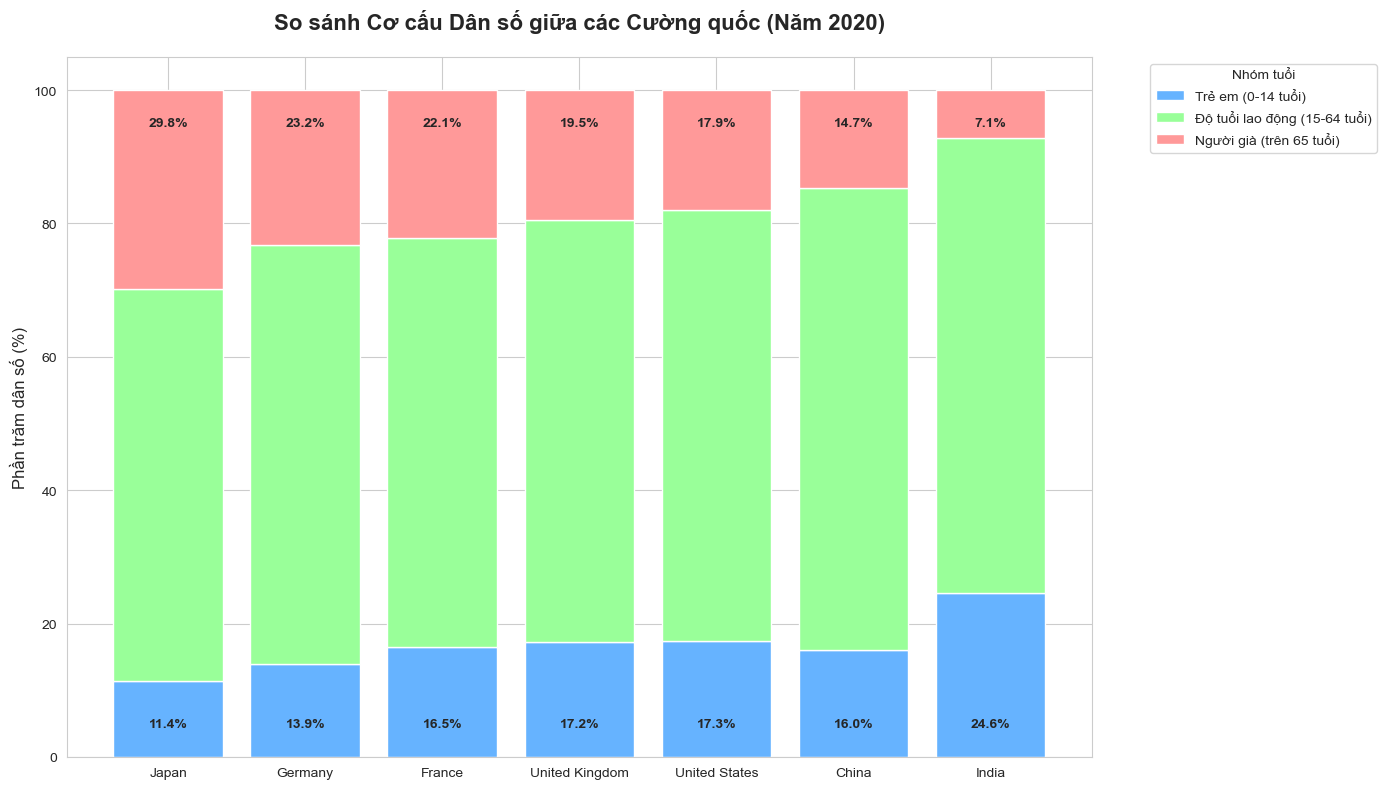

In [9]:
import matplotlib.pyplot as plt

# 1. Lọc dữ liệu cho năm 2020
df_2020 = df_final[df_final['Year'] == 2024].copy()

# 2. Sắp xếp các nước theo tỷ lệ người già (Pop_65_plus) để biểu đồ trông có thứ tự
# Nước già nhất sẽ nằm bên trái, nước trẻ nhất nằm bên phải
df_2020 = df_2020.sort_values('Pop_65_plus', ascending=False)

# 3. Thiết lập vẽ biểu đồ
plt.figure(figsize=(14, 8))

# Vẽ từng phần của cột chồng
# Phần 1: Trẻ em (0-14)
plt.bar(df_2020['Country Name'], df_2020['Pop_0_14'], label='Trẻ em (0-14 tuổi)', color='#66b3ff')

# Phần 2: Độ tuổi lao động (15-64) - Vẽ đè lên trên phần 1
plt.bar(df_2020['Country Name'], df_2020['Pop_15_64'], bottom=df_2020['Pop_0_14'], 
        label='Độ tuổi lao động (15-64 tuổi)', color='#99ff99')

# Phần 3: Người già (65+) - Vẽ đè lên trên tổng của phần 1 và 2
plt.bar(df_2020['Country Name'], df_2020['Pop_65_plus'], 
        bottom=df_2020['Pop_0_14'] + df_2020['Pop_15_64'], 
        label='Người già (trên 65 tuổi)', color='#ff9999')

# 4. Thêm số liệu phần trăm vào giữa các cột (tùy chọn nhưng giúp biểu đồ chuyên nghiệp hơn)
for i, row in df_2020.iterrows():
    # In % người già
    plt.text(row['Country Name'], 95, f"{row['Pop_65_plus']:.1f}%", ha='center', va='center', fontweight='bold')
    # In % trẻ em
    plt.text(row['Country Name'], 5, f"{row['Pop_0_14']:.1f}%", ha='center', va='center', fontweight='bold')

# 5. Trang trí
plt.title('So sánh Cơ cấu Dân số giữa các Cường quốc (Năm 2020)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Phần trăm dân số (%)', fontsize=12)
plt.legend(title='Nhóm tuổi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 105) # Để chừa khoảng trống phía trên cho đẹp

plt.tight_layout()
plt.show()

# PHÂN TÍCH VÀ RÚT RA KẾT LUẬN (MỤC TIÊU 2)

### 1. Phân tích kết quả từ biểu đồ

*   **Nhật Bản - Quốc gia già hóa nhất (29.8%):** Nhật Bản đứng đầu về tỷ lệ người già, chiếm gần 1/3 dân số. Tỷ lệ trẻ em của nước này cũng thấp nhất nhóm (11.4%), cho thấy một xã hội đang thu hẹp quy mô nhân khẩu học.
*   **Ấn Độ - Lợi thế dân số trẻ (24.6%):** Trái ngược hoàn toàn, Ấn Độ có tỷ lệ trẻ em cao nhất và tỷ lệ người già thấp nhất nhóm (chỉ 7.1%). Điều này cho thấy Ấn Độ đang ở giai đoạn hoàng kim của "cơ cấu dân số vàng".
*   **Trung Quốc (14.7% người già):** Tỷ lệ người già của Trung Quốc đã bắt đầu tiệm cận mức của Hoa Kỳ (17.3%), phản ánh áp lực già hóa đang gia tăng nhanh chóng tại quốc gia này dù mức thu nhập bình quân vẫn đang trong giai đoạn đuổi kịp phương Tây.
*   **Sự ổn định của nhóm phương Tây (Mỹ, Anh, Pháp, Đức):** Các quốc gia này có cơ cấu tương đối giống nhau với tỷ lệ lao động (15-64) ổn định quanh mức 63-65%. Tuy nhiên, Đức là quốc gia có mức độ già hóa cao nhất trong nhóm này (23.2%).

### 2. Nhận xét và xu hướng rút ra từ dữ liệu

*   **Sự phân cực nhân khẩu học:** Có một sự chia tách rõ rệt về cấu trúc xã hội giữa các cường quốc châu Á. Trong khi Nhật Bản đã đi sâu vào xã hội già, Ấn Độ lại giữ được sức trẻ, và Trung Quốc đang chuyển dịch nhanh chóng giữa hai trạng thái này.
*   **Gánh nặng phụ thuộc:** Các quốc gia có phần màu đỏ (người già) lớn sẽ phải đối mặt với áp lực chi phí y tế và lương hưu khổng lồ, buộc phải dựa vào công nghệ và tự động hóa để bù đắp sự thiếu hụt lao động.

### 3. Kết luận

Cơ cấu dân số chính là "tử huyệt" hoặc "bệ phóng" cho sức mạnh tương lai của các cường quốc. **Ấn Độ** hiện sở hữu lợi thế lớn nhất về sức lao động. Ngược lại, **Nhật Bản và Đức** đang phải tìm cách vận hành xã hội với một lực lượng lao động đang thu hẹp. Sự khác biệt về cơ cấu tuổi này sẽ là nhân tố quyết định tốc độ tăng trưởng kinh tế và ổn định xã hội của các nước trong những thập kỷ tới.

# Mục tiêu phân tích 3: Mối quan hệ giữa "Giàu có" (Kinh tế) và "Đô thị hóa" (Xã hội) - Năm 2020

### 1. Chỉ số sử dụng

*   **Trường dữ liệu:** 
    *   `GDP per capita (current US$)` - GDP bình quân đầu người (Đại diện cho sức mạnh kinh tế).
    *   `Urban population (% of total population)` - Tỷ lệ dân số đô thị (Đại diện cho sự chuyển dịch xã hội).
*   **Ý nghĩa của chỉ số:** Kết hợp hai chỉ số này giúp đo lường mức độ tương quan giữa sự thịnh vượng về mặt tài chính và quá trình hiện đại hóa lối sống của cư dân tại một quốc gia.

### 2. Giải thích lý do lựa chọn trường dữ liệu

*   **Phù hợp với mục tiêu:** Đây là bước phân tích kết nối (Cross-domain analysis). Mục tiêu là kiểm chứng giả thuyết: "Sự phát triển kinh tế là động lực chính thúc đẩy quá trình đô thị hóa".
*   **Giải thích tại sao lựa chọn:** Việc lựa chọn hai trường dữ liệu này giúp nhóm không chỉ nhìn các chỉ số một cách rời rạc mà còn tìm ra quy luật phát triển chung của các cường quốc: Khi thu nhập tăng cao, cơ cấu xã hội chuyển dịch từ nông nghiệp/nông thôn sang công nghiệp - dịch vụ/thành thị.

### 3. Loại biểu đồ: **Scatter Plot (Biểu đồ phân tán)**

### 4. Giải thích lý do lựa chọn

*   **Tính chất dữ liệu:** Biểu đồ phân tán là tiêu chuẩn vàng để thể hiện mối tương quan (Correlation) giữa hai biến số định lượng. 
*   **Khả năng so sánh:** Với đường xu hướng (Trend line) và vùng tin cậy, biểu đồ giúp xác định rõ các nước nào đang đi đúng lộ trình phát triển chung, nước nào là "ngoại lệ" hoặc có tiềm năng bứt phá.
*   **Sự trực quan:** Việc sử dụng các dấu chấm có kích thước lớn và gắn nhãn trực tiếp giúp người xem nhận diện ngay lập tức vị thế của từng quốc gia trên "bản đồ thịnh vượng".

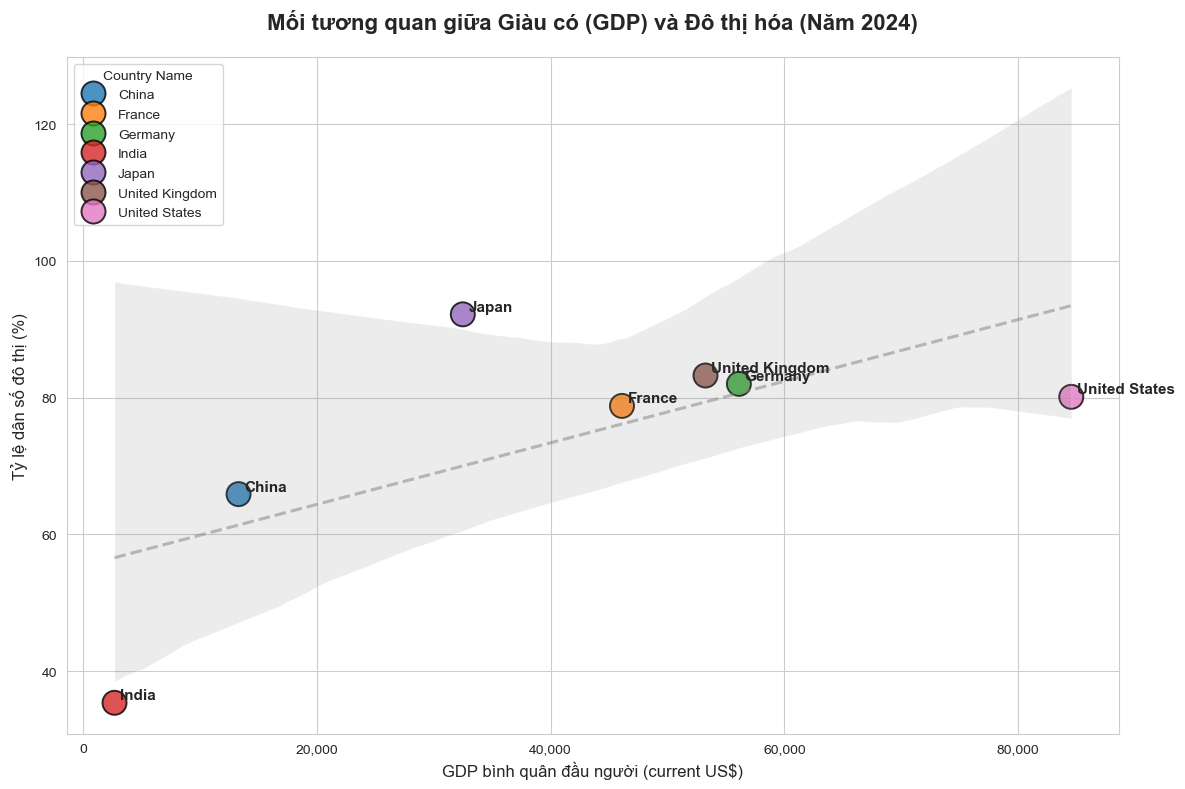

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lọc dữ liệu cho năm 2020
df_2020 = df_final[df_final['Year'] == 2024].copy()

# 2. Thiết lập vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 3. Vẽ biểu đồ phân tán
# s=200 để các chấm to và dễ nhìn hơn
scatter = sns.scatterplot(
    data=df_2020, 
    x='GDP_per_capita', 
    y='Urban_Population', 
    hue='Country Name', 
    s=300, 
    alpha=0.8,
    edgecolor='black'
)

# 4. QUAN TRỌNG: Thêm tên nước cạnh mỗi dấu chấm
# Vì chỉ có 7 nước, việc ghi tên trực tiếp giúp người xem không cần nhìn bảng chú thích
for i in range(df_2020.shape[0]):
    plt.text(
        x=df_2020.GDP_per_capita.iloc[i] + 500, # Dịch sang phải một chút
        y=df_2020.Urban_Population.iloc[i] + 0.5, # Dịch lên trên một chút
        s=df_2020['Country Name'].iloc[i], 
        fontsize=11, 
        fontweight='bold'
    )

# 5. Vẽ một đường xu hướng (Trend line) để thấy rõ mối tương quan
sns.regplot(
    data=df_2020, 
    x='GDP_per_capita', 
    y='Urban_Population', 
    scatter=False, 
    color='gray', 
    line_kws={"ls":"--", "alpha":0.5}
)

# 6. Trang trí biểu đồ
plt.title('Mối tương quan giữa Giàu có (GDP) và Đô thị hóa (Năm 2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GDP bình quân đầu người (current US$)', fontsize=12)
plt.ylabel('Tỷ lệ dân số đô thị (%)', fontsize=12)

# Định dạng trục X hiển thị dấu phẩy ngăn cách hàng nghìn cho dễ đọc
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# PHÂN TÍCH VÀ RÚT RA KẾT LUẬN (MỤC TIÊU 3)

### 1. Phân tích kết quả từ biểu đồ

*   **Mối tương quan thuận rõ rệt:** Đường đứt đoạn đi lên và vùng phủ xám cho thấy một xu hướng chung: GDP bình quân đầu người càng cao thì tỷ lệ đô thị hóa càng lớn.
*   **Nhật Bản - Ngoại lệ về Đô thị hóa:** Mặc dù không phải là nước có GDP cao nhất (khoảng 40.000 USD), Nhật Bản lại có tỷ lệ đô thị hóa cao nhất nhóm (vượt ngưỡng 90%), cho thấy một xã hội tập trung cực kỳ cao vào các siêu đô thị.
*   **Hoa Kỳ - Cường quốc giàu có nhất:** Mỹ nằm ở vị trí xa nhất bên phải trục hoành (GDP vượt 60.000 USD). Tuy nhiên, tỷ lệ đô thị hóa của Mỹ (80%) lại thấp hơn Nhật Bản và Anh, cho thấy đặc điểm quy hoạch dân cư dàn trải hơn của quốc gia này.
*   **Trung Quốc và Ấn Độ - Nhóm đang phát triển:** Trung Quốc đã vươn lên mức thu nhập trung bình (10.000 USD) với tỷ lệ đô thị hóa trên 60%. Trong khi đó, Ấn Độ nằm ở góc dưới cùng bên trái với mức thu nhập và đô thị hóa thấp nhất, thể hiện sự khác biệt lớn về trình độ phát triển so với các nước còn lại.

### 2. Nhận xét và xu hướng rút ra từ dữ liệu

*   **Quy luật phát triển xã hội:** Quá trình đô thị hóa diễn ra mạnh mẽ nhất khi GDP bình quân đầu người vượt ngưỡng 10.000 USD (trường hợp của Trung Quốc).
*   **Sự bão hòa:** Tại các nước có GDP trên 40.000 USD, tỷ lệ đô thị hóa có xu hướng bão hòa và đi ngang trong khoảng 80-92%, tập trung vào việc nâng cao chất lượng sống tại đô thị thay vì mở rộng số lượng.

### 3. Kết luận

Kết quả phân tích khẳng định **sức mạnh kinh tế là nền tảng thúc đẩy sự chuyển dịch xã hội**. Một cường quốc thực thụ không chỉ cần giàu có mà còn cần một xã hội hiện đại hóa cao (thể hiện qua đô thị hóa). **Trung Quốc** đang đi đúng lộ trình của các nước phát triển để trở thành một xã hội đô thị hóa toàn diện. Trong khi đó, **Ấn Độ** vẫn còn dư địa khổng lồ để thúc đẩy kinh tế thông qua việc đẩy mạnh đô thị hóa trong những thập kỷ tới.

# Mục tiêu phân tích 4: Tốc độ phổ cập Internet và sự hình thành Xã hội số (2000 - 2022)

### 1. Chỉ số sử dụng

*   **Trường dữ liệu:** `Individuals using the Internet (% of population)` - Tỷ lệ người dân sử dụng Internet.
*   **Ý nghĩa của chỉ số:** Chỉ số này đo lường tỷ lệ phần trăm dân số có quyền truy cập và sử dụng mạng Internet toàn cầu. Đây là thước đo cốt lõi để đánh giá mức độ số hóa của một xã hội.

### 2. Giải thích lý do lựa chọn trường dữ liệu

*   **Phù hợp với mục tiêu:** Trong kỷ nguyên 4.0, sức mạnh xã hội của một cường quốc gắn liền với khả năng kết nối số. Chỉ số Internet phản ánh trình độ dân trí kỹ thuật số, khả năng tiếp cận thông tin và hạ tầng phục vụ kinh tế số.
*   **Giải thích tại sao lựa chọn:** Việc so sánh chỉ số này giúp chúng ta thấy được tốc độ lan tỏa của công nghệ thông tin trên toàn cầu. Nó giúp trả lời câu hỏi: "Các quốc gia mới nổi (Trung Quốc, Ấn Độ) đã thu hẹp khoảng cách công nghệ với phương Tây nhanh như thế nào?"

### 3. Loại biểu đồ: **Heatmap (Bản đồ nhiệt)**

### 4. Giải thích lý do lựa chọn

*   **Tính chất dữ liệu:** Heatmap là loại biểu đồ xuất sắc nhất để thể hiện dữ liệu đa chiều (Quốc gia x Năm x Giá trị) mà không gây rối mắt.
*   **Khả năng so sánh:** Việc sử dụng thang màu từ nhạt (vàng) đến đậm (xanh) giúp người xem nhận diện ngay lập tức "làn sóng" công nghệ số lan tỏa qua từng giai đoạn 5 năm.
*   **Sự trực quan:** Heatmap cho phép so sánh đồng thời sự phát triển của một quốc gia theo thời gian (hàng ngang) và sự khác biệt giữa các quốc gia tại một thời điểm (hàng dọc) một cách vô cùng sinh động.

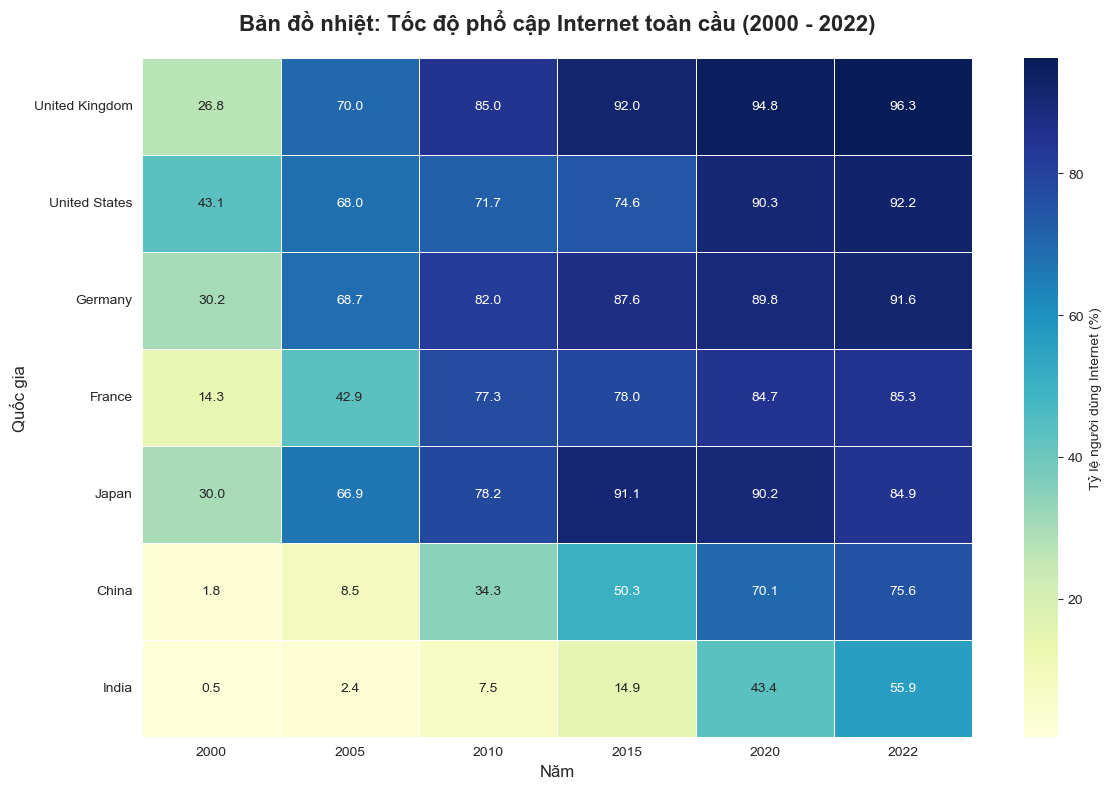

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu: Lọc các mốc năm 5 năm một lần để biểu đồ không bị quá dày
years_sampled = [2000, 2005, 2010, 2015, 2020, 2022]
df_internet = df_final[df_final['Year'].isin(years_sampled)]

# 2. Xây dựng bảng Pivot cho Heatmap: Dòng là Country, Cột là Year, Giá trị là Internet_Usage
heatmap_data = df_internet.pivot(index="Country Name", columns="Year", values="Internet_Usage")

# Sắp xếp các nước theo tỷ lệ năm 2020 để biểu đồ trông chuyên nghiệp hơn (từ cao xuống thấp)
heatmap_data = heatmap_data.sort_values(by=2022, ascending=False)

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 8))
sns.set_style("white")

# annot=True để hiện con số trực tiếp trên ô, fmt=".1f" để lấy 1 chữ số thập phân
# cmap='YlGnBu' (Vàng - Xanh lá - Xanh dương) rất hợp để thể hiện sự tăng trưởng
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", 
            linewidths=.5, cbar_kws={'label': 'Tỷ lệ người dùng Internet (%)'})

# 4. Trang trí biểu đồ
plt.title('Bản đồ nhiệt: Tốc độ phổ cập Internet toàn cầu (2000 - 2022)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Quốc gia', fontsize=12)

plt.tight_layout()
plt.show()

# PHÂN TÍCH VÀ RÚT RA KẾT LUẬN (MỤC TIÊU 4)

### 1. Phân tích kết quả từ biểu đồ

*   **Sự chuyển mình toàn diện (Dòng chảy màu sắc):** Biểu đồ chuyển dần từ màu vàng nhạt (năm 2000) sang màu xanh đậm đặc (năm 2022). Điều này cho thấy Internet từ một dịch vụ xa xỉ đã trở thành nền tảng thiết yếu cho tất cả các cường quốc.
*   **Nhóm dẫn đầu tuyệt đối (UK, USA, Germany):** Các nước này đạt tỷ lệ phổ cập trên 90% vào năm 2022. Đặc biệt là **Vương quốc Anh (UK)** dẫn đầu với 96.3%, cho thấy một xã hội đã số hóa gần như hoàn toàn.
*   **Tốc độ thần tốc của Trung Quốc:** Từ mức chỉ 1.8% năm 2000 (màu vàng nhạt nhất), Trung Quốc đã nhảy vọt lên 75.6% vào năm 2022. Đây là minh chứng cho chiến lược phát triển hạ tầng số mạnh mẽ nhất thế giới.
*   **Ấn Độ và bước nhảy muộn:** Ấn Độ dù có xuất phát điểm thấp nhất (0.5% năm 2000) và vẫn giữ màu nhạt trong thời gian dài, nhưng đã có bước bứt phá cực lớn trong giai đoạn 2015 - 2022 (tăng từ 14.9% lên 55.9%).

### 2. Nhận xét và xu hướng rút ra từ dữ liệu

*   **Xóa bỏ khoảng cách số (Closing the Digital Divide):** Khoảng cách về công nghệ số giữa các cường quốc phương Đông và phương Tây đang được lấp đầy nhanh chóng. Màu sắc của Trung Quốc năm 2022 đã tương đồng với màu sắc của các nước phát triển giai đoạn 2010-2015.
*   **Sự bão hòa:** Tại các nước phát triển, tỷ lệ Internet bắt đầu đi vào ngưỡng bão hòa (trên 90%), lúc này cạnh tranh xã hội sẽ chuyển từ "số lượng người dùng" sang "chất lượng kết nối" và "công nghệ lõi".

### 3. Kết luận

Internet chính là "hệ thần kinh" của các cường quốc hiện đại. Phân tích cho thấy **Vương quốc Anh và Mỹ** vẫn giữ vị thế tiên phong trong xã hội số. Tuy nhiên, sự bùng nổ của **Trung Quốc và Ấn Độ** cho thấy các quốc gia này đang tận dụng công nghệ để thực hiện những cú "nhảy cóc" về trình độ xã hội, tạo nên một cục diện thế giới phẳng và kết nối hơn bao giờ hết.